**In this Notebook we will do the following:**

- Construct the Pauli-Transfer-Matrix (PTM) of multiple Circuits
    - Memory Round: Surface Code
    - Lattice Surgery

- Invert the PTM to get an estimate of the Logical Operator

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\Users\f.spreemann\qecsim-work


In [3]:
from src.core.data_models import NoiseParameters
from src.tools.qem_estimator.logical_level.calc_ptm import PTMCalculator
from src.core.data_models import PTMCircuits
from src.codes.lattice_surgery.builder import SurgeryBuilder
from itertools import product
from tqdm import tqdm
import gc

import stim

**PTM Calculation: Lattice Surgery**

In [4]:
#########################
# Construct Noise Class #
#########################
noise = 0.0

noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

############
# Circuits #
############

# Pauli alphabet for input and output states
PAULIS = ["I", "X", "Y", "Z"]

# Create Mapping for input states
input_to_init_state = {
    "X": ["X+", "X-"],
    "Y": ["Y+", "Y-"],
    "Z": ["Z0", "Z1"],
    "I": ["I0", "I1"],
}

circuits_surgery: dict[str, tuple[dict[str, stim.Circuit], list[int]]] = {}

# We combine the products so the progress bar tracks all 256 combinations
total_combinations = list(product(PAULIS, PAULIS, PAULIS, PAULIS))

for p_out_c, p_out_t, p_in_c, p_in_t in tqdm(total_combinations, desc="Generating Circuits"):

    # Initialize current measurement records and Circuit list
    curr_meas_rec: list[int] = []
    all_circuits: list[stim.Circuit] = []

    # Creating Label
    label_basis = f"{p_in_c}{p_in_t}->{p_out_c}{p_out_t}"

    # As the II->II flow has no observable, no flip prediction
    # by the decoder can be made!
    if label_basis == "II->II":
        continue

    # Creating inner dict
    inner_dict: dict[str, stim.Circuit] = {}

    # Inner loop for the 4 initial states
    for init_state_c, init_state_t in product(input_to_init_state[p_in_c], input_to_init_state[p_in_t]):
        # Creating state Label
        state_label = f"{init_state_c},{init_state_t}"

        builder = SurgeryBuilder(
            distance=3,
            control_state_init=init_state_c,
            target_state_init=init_state_t,
            control_measure_basis=p_out_c,
            target_measure_basis=p_out_t,
            noise=noise_class
        )

        circuit = builder.build_circuit()
        all_circuits.append(circuit)

        # It doesnt matter which records we get as the logical observable stays the same
        # in this loop
        curr_meas_rec = builder.get_logical_meas_rec(observable_index=0)

        # Adding the circuit to the inner dict
        inner_dict[state_label] = circuit

    # Adding to your existing dict
    circuits_surgery[label_basis] = (inner_dict, curr_meas_rec)

Generating Circuits: 100%|██████████| 256/256 [02:51<00:00,  1.49it/s]


In [5]:
import numpy as np

np.set_printoptions(precision=4, suppress=True, linewidth=200)

############################
# Calculate the PTM-Matrix #
############################

ptm_calculator = PTMCalculator(PTMCircuits(circuits=circuits_surgery), samples=1_000)
ptm_ideal = ptm_calculator.calc_ptm(only_non_zero=False)

# Clear Dict
circuits_surgery.clear()
gc.collect()

0

In [6]:
#########################
# Construct Noise Class #
#########################
noise = 1e-4

noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

############
# Circuits #
############

# Pauli alphabet for input and output states
PAULIS = ["I", "X", "Y", "Z"]

# Create Mapping for input states
input_to_init_state = {
    "X": ["X+", "X-"],
    "Y": ["Y+", "Y-"],
    "Z": ["Z0", "Z1"],
    "I": ["I0", "I1"],
}

circuits_surgery: dict[str, tuple[dict[str, stim.Circuit], list[int]]] = {}

# We combine the products so the progress bar tracks all 256 combinations
total_combinations = list(product(PAULIS, PAULIS, PAULIS, PAULIS))

for p_out_c, p_out_t, p_in_c, p_in_t in tqdm(total_combinations, desc="Generating Circuits"):

    # Initialize current measurement records and Circuit list
    curr_meas_rec: list[int] = []
    all_circuits: list[stim.Circuit] = []

    # Creating Label
    label_basis = f"{p_in_c}{p_in_t}->{p_out_c}{p_out_t}"

    # As the II->II flow has no observable, no flip prediction
    # by the decoder can be made!
    if label_basis == "II->II":
        continue

    # Creating inner dict
    inner_dict: dict[str, stim.Circuit] = {}

    # Inner loop for the 4 initial states
    for init_state_c, init_state_t in product(input_to_init_state[p_in_c], input_to_init_state[p_in_t]):
        # Creating state Label
        state_label = f"{init_state_c},{init_state_t}"

        builder = SurgeryBuilder(
            distance=3,
            control_state_init=init_state_c,
            target_state_init=init_state_t,
            control_measure_basis=p_out_c,
            target_measure_basis=p_out_t,
            noise=noise_class
        )

        circuit = builder.build_circuit()
        all_circuits.append(circuit)

        # It doesnt matter which records we get as the logical observable stays the same
        # in this loop
        curr_meas_rec = builder.get_logical_meas_rec(observable_index=0)

        # Adding the circuit to the inner dict
        inner_dict[state_label] = circuit

    # Adding to your existing dict
    circuits_surgery[label_basis] = (inner_dict, curr_meas_rec)

Generating Circuits: 100%|██████████| 256/256 [04:39<00:00,  1.09s/it]


In [7]:
############################
# Calculate the PTM-Matrix #
############################

ptm_calculator = PTMCalculator(PTMCircuits(circuits=circuits_surgery), samples=1_000)
ptm_noisy = ptm_calculator.calc_ptm(only_non_zero=False)

# Clear Dict
circuits_surgery.clear()
gc.collect()

0

**Logical-Estimator**

We now use the Noisy and the Ideal PTM in order to build the logical estimator

In [8]:
from src.tools.qem_estimator.logical_level.logical_estimator_surgery import LogicalEstimatorSurgery

# Set II entry on both to one
ptm_ideal[0, 0] = 1
ptm_noisy[0, 0] = 1

# Building Class
cls = LogicalEstimatorSurgery(ptm_clean=ptm_ideal, ptm_noisy=ptm_noisy)

In [15]:
# Get NoiseParamters
noise = 1e-4


noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

# Create Circuit which should be sampled
builder = SurgeryBuilder(
            distance=5,
            control_state_init="Z0",
            target_state_init="Y-",
            control_measure_basis="I",
            target_measure_basis="Y",
            noise=noise_class
)

circuit = builder.build_circuit()
measurement_records = builder.get_logical_meas_rec(observable_index=0)

# Sample Circuit
expectation_val = cls.sample_circuit(circuit, measurement_records, meas_basis="IY", shots=1_000)
print(f"Expectation Value: {expectation_val}")
cls.gamma

Expectation Value: -0.9985849890390817


np.float64(1.012763680567045)

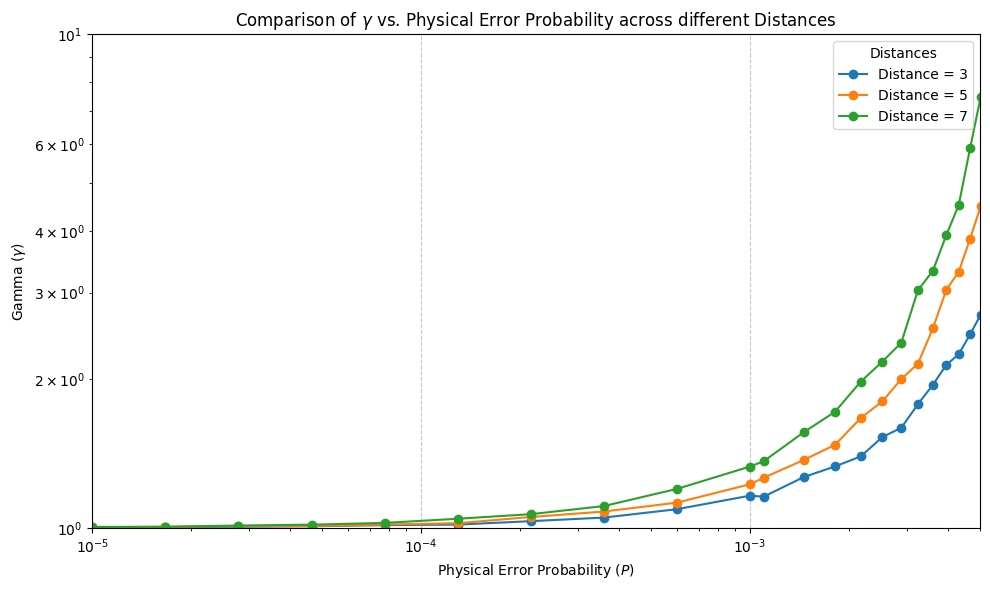

In [ ]:
# Load Results from file
import pandas as pd
results = pd.read_csv("results.csv")

# Display the results
import matplotlib.pyplot as plt

# Sort the dataframe by probability to ensure the lines are drawn correctly
results_sorted = results.sort_values(by=['distance', 'physical_error_probability'])

# Create the plot
plt.figure(figsize=(10, 6))

# Group by 'distance' and plot each group separately
unique_distances = sorted(results_sorted['distance'].unique())

for dist in unique_distances:
    subset = results_sorted[results_sorted['distance'] == dist]
    plt.plot(subset['physical_error_probability'], subset['gamma'], marker='o', label=f'Distance = {dist}')

# Add labels using LaTeX formatting
plt.xlabel(r'Physical Error Probability ($P$)')
plt.ylabel(r'Gamma ($\gamma$)')
plt.title(r'Comparison of $\gamma$ vs. Physical Error Probability across different Distances')

# Add legend, grid, and layout formatting
plt.legend(title='Distances')
plt.grid(True, which= "both", linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.xlim(1e-5, 5e-3)
plt.ylim(1, 10)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()

# Save or show the plot
plt.savefig('gamma_plot.png', dpi=300)
plt.show()